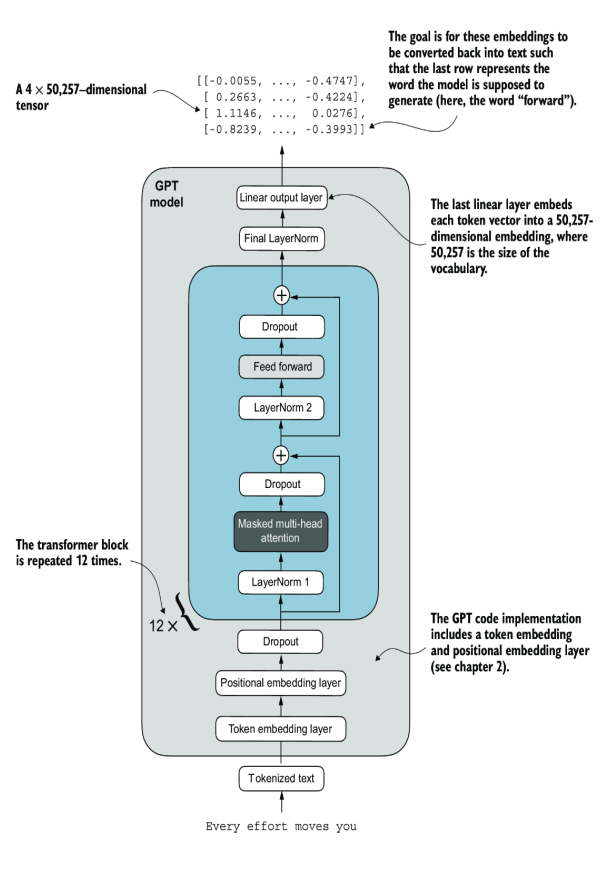

### We will this entire structure bottom to top 

Lets first understand step by step how the input is handled in each step and what the dimensionality in each step

 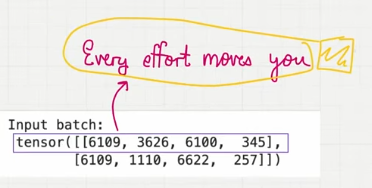

 here out task will be to predict the next token i.e. "forward" in this case. 

 Ideally data comes in batches, here we will consider two batches with 4 tokens each. 

 So in the above pic the first tensor is for the first batch "every effort moves you" which has 4 tokens

 Similarly the second batch is for any other sentence

 For now we will focus only on the first dimension


 So in the first step we map each token with their respective token ids, which were learnt by the tokenizer during training. There are 50,257 vocabs in the GPT tokenizer 

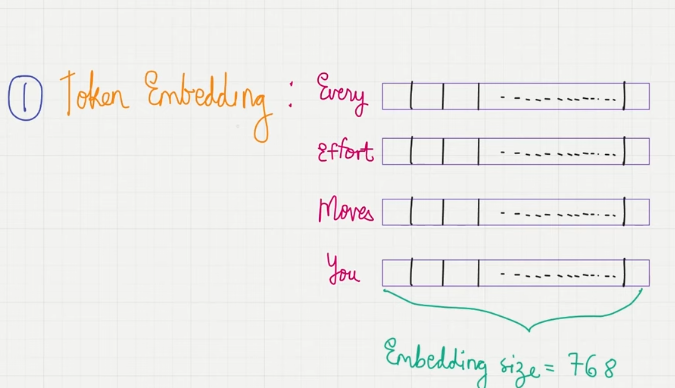

This the second step, as mahcines can't understand words and the token ids can't justify the meaning of any word. So we use embedding which captures the semantic meaning of any token. 

The embedding layer is also trained while training LLM, and the result forms a look up table which consist of vector embedding of fixed dimension for each of token present in the vocabulary of the tokenizer. 

In GPT the embedding dimension taken in 768. So the dimensionality of the look up table will be 50257x768

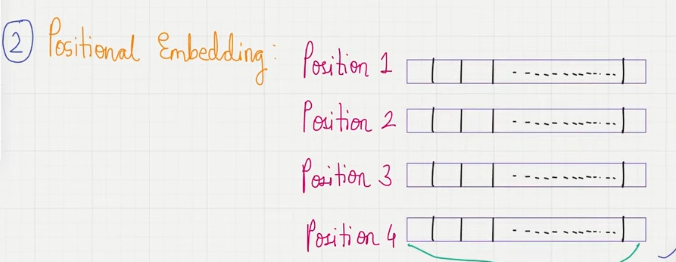

Along with the semantic meaning of the word, its position where it comes in the sequence also matters as neither the attention mechanism nor the token embedding emphasize upon the position we have this addition positional embedding layer, which has an embedding of the same dimension as the token membedding for each position. 

The dimensionality of the position embedding weight matrix depends upon the context lenght and the embedding dimension, in our case with 4 tokens as the context length the dimensions of the look up table will 4x768

These are also randomly intialized and trained during LLM training

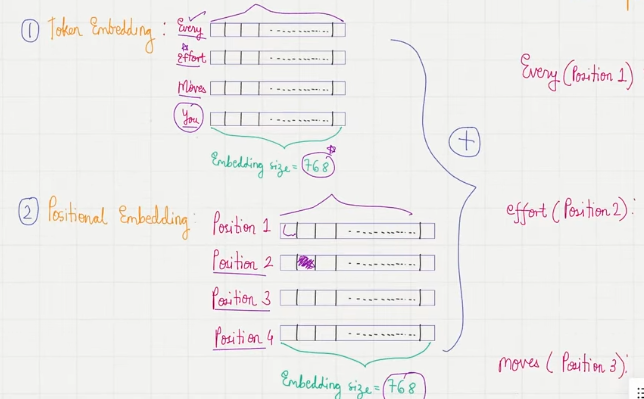

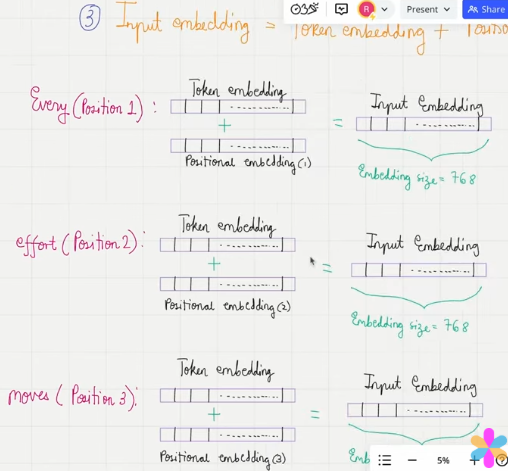

Here now we will calculate the input embedding by summing up the token and positional embedding toghether. As the dimensions of both of them are same, it's easy to add them up toghether. 

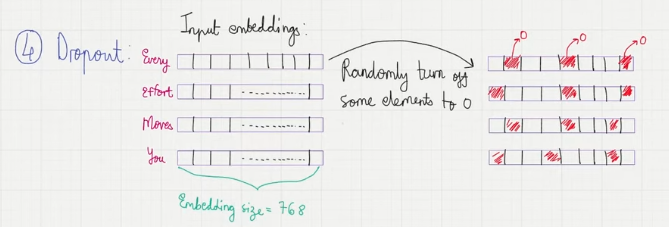

in dropout we randomly turn off some element from every input embedding to 0, this done to resist overfitting and to make the model genralize well. This is only done in training, during inferencing all the nodes are turned on by disabling drop out.

If drop out rate is 50%, randomly 50% of the wieghts are made 0 in input embedding

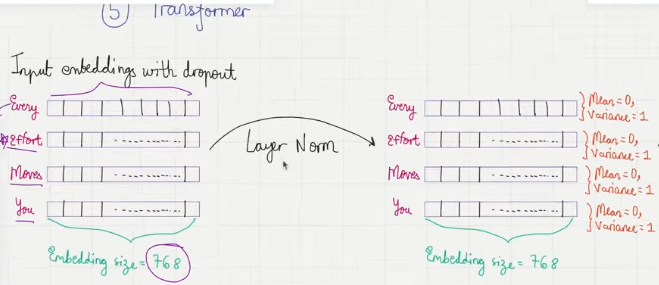

Once we have the input embeddings now we normalize the tokens embeddings wrt to each tokens using this normalization layer. 

What it does? 

Makes each input embedding mean as 0 and variance as 1. 

It takes each token wrt to embedding dimension, calculates thee mean and variance then normalize them using the formula where each feature is subtracted by mean and then divided by sqrt of variance. 

Why do we do it?

1. It stabilizes the gradient and training (prevent explosive and vanishing gradients)
2. As the different input provided can have different distribuition which can lead to slower diversion, it converts all the inputs to normal distribution (mean 0, variance 1) which solves this problem of slow convergence. This whole phenomenon is knonwn as **Internal Covariate Shift**


**Difference between Layer and batch normalization?**

Layer Norm works on independent tokens , calculate the mean and variance wert to their dimensions and then normalize them. 

While Batch Normalization depends on batch, it calculates mean and variance for each feature in all the token in the batch. 

Why not to use batch normalization in LLMs?

The batch norm creates a dependency between all the tokens, which is not requried in the LLMs

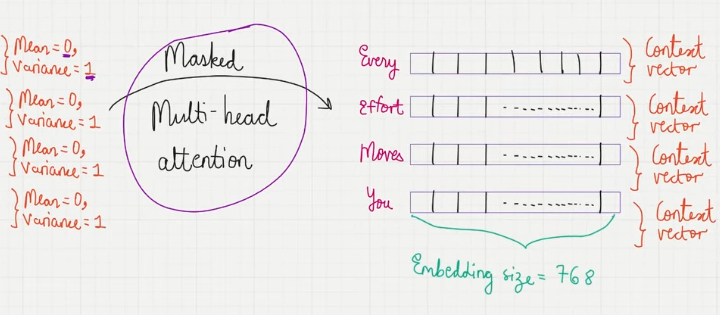

Once we have calculated the input embeddings, we have encoded the semantic and positional meaning of the tokens. But there is one more thing that needs to be taken care of, the meaning of the words also depends upon how they are used in a sentence. 

This thing is encoded using the **masked multi-head attention mechanism**, which results in the context vectors once applied, these context vectors are created while keeping in mind how much attention should be given to other words when we are looking at a certain word.

This helps when we are prediciting new words which are most important words to look at etc.

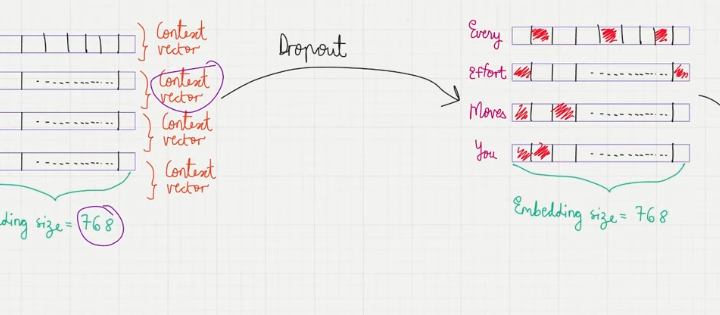

again a dropout layer for reducing over fitting

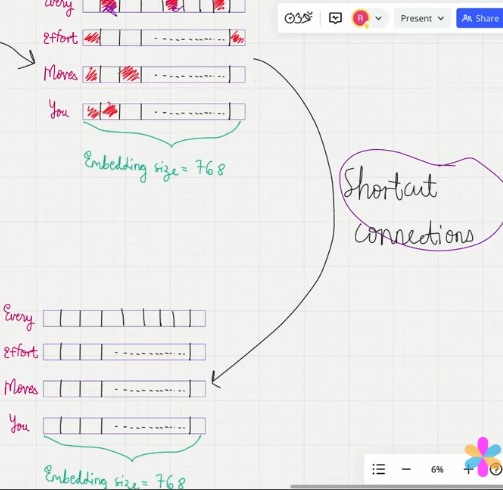


Now we have the shortcut connection here, where we add the input embedding with the this droped out context vector. 

The main reason the shortcut connections are used is that they help in preventing the vanishing gradient. 


  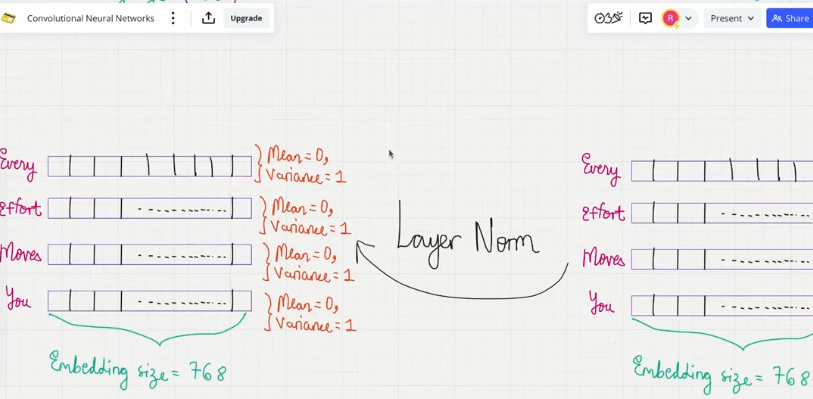

  Again normalization 

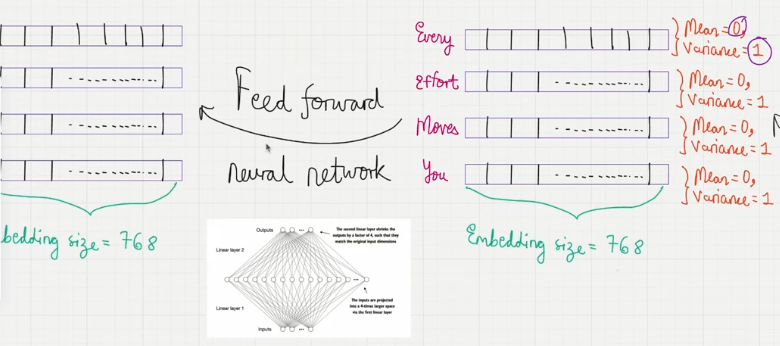

Now we have the feed forward layer, which does the expansion and contraction procedure. 

It performs the process on individual tokens. 

FFN operates on each token separately (unlike attention).

Expands dimensions → Non-linearity → Projects back.

Essential for richer feature transformation.

Adds more parameters, making models more expressive.

**IMP: Self-attention extracts relationships between tokens, while FFN refines individual token representations.**

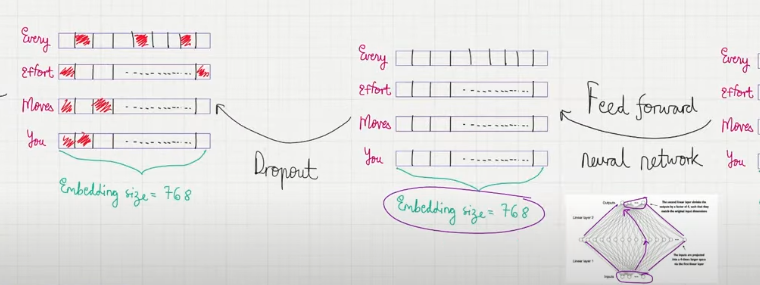

Another dropout layer

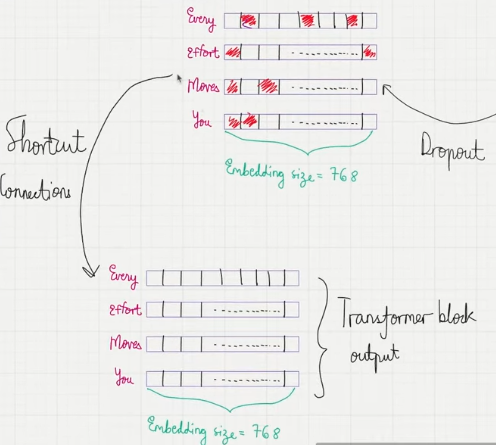

Shortcut connection with the output of the self attention with this output.

And this is the final output from the transformer block 

Now after these there are two more post processing steps which are present in the GPT architecture. 

1. Layer Normalizaton 
2. Linear Output Layer

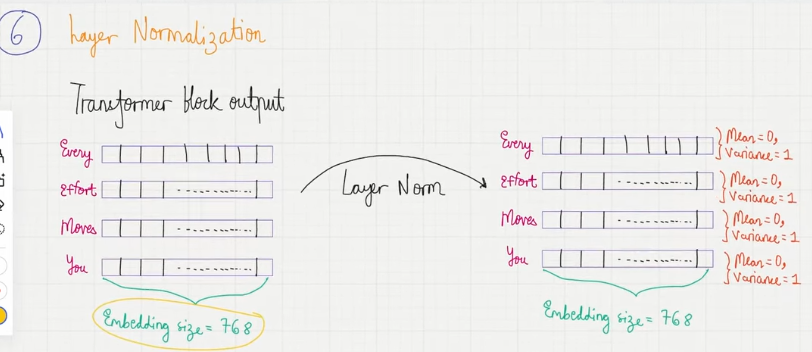

Layer Norm

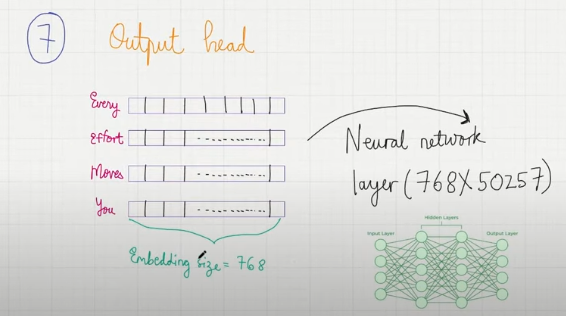

This is the last stage in the architecture, where we pass the tranformer output of dimension 4x768 through a NN layer which has the dimension of 768x50257. Which results in Logits of dimensions 4x50257

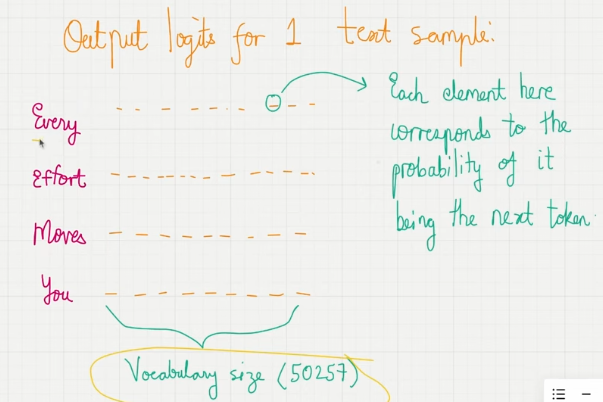

**As you have seen the last step is the only one where the dimensions of the input vector changed rest in the whole architecture, the dimensions were same all the time, this is done intentionally to make these scalable and so that multiple layers can be stakced toghether**

There are 4 prediction task, thats why there are 4 rows, --IMP

In [ ]:
#lets code it 
import torch
from torch import nn

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 768,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer(
            "mask",
            torch.triu(torch.ones(context_length, context_length),
                       diagonal=1)
        )

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x) # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim) 
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)
        
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2) 
        
        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec) # optional projection

        return context_vec


class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) * 
            (x + 0.044715 * torch.pow(x, 3))   #this is the function which is actually used for calculating gelu, this is an approximation of the original 
            #cumulative distributive fucntion of gradient distribution 
        ))

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential( #sequential is a pytorch for stacking and chaining the layers toghther to create a nn
            nn.Linear(cfg["emb_dim"], 4 * cfg['emb_dim']),  #expands four times the dimension
            #input to the layer is the org embed dim, while output is 4 times the original dim 
            GELU(), #activation functin from above class
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"])  #contracts back to original by reducing 4 times
            #input is 4 times the org dim, as given by the prev linear layer and output is 4 times shrinked dimenension equal to the org.
        )
    
    def forward(self, x):
        return self.layers(x)

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim)) #a hyperparameter which will be trained, has the same dimension as the input 
        self.shift = nn.Parameter(torch.zeros(emb_dim))#another hyperparameter which will be added that's why 0

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x-mean) / torch.sqrt(var + self.eps)  #eps is added so that if in any case var becomes 0 the entire term don't become 0 
        return self.scale * norm_x + self.shift #scale and shift are hyperparams which will be trained 
    #you can see here why scale was made all 1 and shift as all 0s


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"]
        )
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):

        #shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)  #first normalization layer 
        x = self.att(x) #shape [batch_size, num_tokens, emb_size]  #created context vector by passing masked multi head attention 
        x = self.drop_shortcut(x) #drop 10% neurons randomly 
        x = x + shortcut #add the original input back - shortcut connection 

        #shortcut connection for feed forward block 
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])  #token embeddings 50257x768
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"]) #positional embeddings 4x768       
        self.drop_emb = nn.Dropout(cfg["drop_rate"])
        
        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])  #12 transformer layers 
        
        self.final_norm = LayerNorm(cfg["emb_dim"])  #final norm layer
        self.out_head = nn.Linear(
            cfg["emb_dim"], cfg["vocab_size"], bias=False
        ) #final output layer to create logits 768x50257

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx) #50257x768
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device)) #4x768
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size] #4x768
        x = self.drop_emb(x) #4x768
        x = self.trf_blocks(x) #4x768
        x = self.final_norm(x) #4x768
        logits = self.out_head(x) #4x768 x 768x50257
        return logits #4x50257

The init constructor of this GPTModel class initializes the token and positional embedding layers using the configurations passed in via a Python dictionary, cfg.

These embedding layers are responsible for converting input token indices into dense vectors and adding positional information.

Next, the init method creates a sequential stack of TransformerBlock modules equal to the number of layers specified in cfg.

Following the transformer blocks, a LayerNorm layer is applied, standardizing the outputs from the transformer blocks to stabilize the learning process.

Finally, a linear output head without bias is defined, which projects the transformer's output into the vocabulary space of the tokenizer to generate logits for each token in the vocabulary.

The forward method takes a batch of input token indices, computes their embeddings, applies the positional embeddings, passes the sequence through the transformer blocks, normalizes the final output, and then computes the logits, representing the next token's unnormalized probabilities. We will convert these logits into tokens and text outputs in the next section.


In [4]:
#Let's now initialize the 124 million parameter GPT model using the GPT_CONFIG_124M dictionary
#  we pass into the cfg parameter and feed it with the batch text input we created at the beginning


import tiktoken
torch.manual_seed(123)

tokenizer = tiktoken.get_encoding("gpt2")
batch = []
txt1 = "Every effort moves you"
txt2 = "Every day holds a"
batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)

model = GPTModel(GPT_CONFIG_124M)
out = model(batch)
print("Input batch:\n", batch)
print("\nOutput shape:", out.shape)
print(out)

Input batch:
 tensor([[6109, 3626, 6100,  345],
        [6109, 1110, 6622,  257]])

Output shape: torch.Size([2, 4, 50257])
tensor([[[ 0.1381,  0.0077, -0.1963,  ..., -0.0222, -0.1060,  0.1717],
         [ 0.3865, -0.8408, -0.6564,  ..., -0.5163,  0.2369, -0.3357],
         [ 0.6989, -0.1829, -0.1631,  ...,  0.1472, -0.6504, -0.0056],
         [-0.4290,  0.1669, -0.1258,  ...,  1.1579,  0.5303, -0.5549]],

        [[ 0.1094, -0.2894, -0.1467,  ..., -0.0557,  0.2911, -0.2824],
         [ 0.0882, -0.3552, -0.3527,  ...,  1.2930,  0.0053,  0.1898],
         [ 0.6091,  0.4702, -0.4094,  ...,  0.7688,  0.3787, -0.1974],
         [-0.0612, -0.0737,  0.4751,  ...,  1.2463, -0.3834,  0.0609]]],
       grad_fn=<UnsafeViewBackward0>)


As we can see, the output tensor has the shape [2, 4, 50257], since we passed in 2 input texts with 4 tokens each. The last dimension, 50,257, corresponds to the vocabulary size of the tokenizer. In the next section, we will see how to convert each of these 50,257- dimensional output vectors back into tokens.

Using the numel() method, short for "number of elements," we can collect the total number of parameters in the model's parameter tensors:

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")  #163M !!!

Total number of parameters: 163,009,536


### IMP 
Earlier, we spoke of initializing a 124 million parameter GPT model, so why is the actual number of parameters 163 million, as shown in the preceding code output?
The reason is a concept called weight tying that is used in the original GPT-2 architecture, which means that the original GPT-2 architecture is reusing the weights from the token embedding layer in its output layer.

In [6]:
print("Token embedding layer shape:", model.tok_emb.weight.shape)
print("Output layer shape:", model.out_head.weight.shape)

Token embedding layer shape: torch.Size([50257, 768])
Output layer shape: torch.Size([50257, 768])



As we can see based on the print outputs, the weight tensors for both these layers have the same shape:

The token embedding and output layers are very large due to the number of rows for the 50,257 in the tokenizer's vocabulary. Let's remove the output layer parameter count from the total GPT-2 model count according to the weight tying:

In [7]:
total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Number of trainable parameters considering weight tying: 124,412,160


As we can see, the model is now only 124 million parameters large, matching the original size of the GPT-2 model.

Weight tying reduces the overall memory footprint and computational complexity of the model. However, in my experience, using separate token embedding and output layers results in better training and model performance; hence, we are using separate layers in our GPTModel implementation. The same is true for modern LLMs.

Lastly, let us compute the memory requirements of the 163 million parameters in our GPTModel object

In [ ]:
total_size_bytes = total_params * 4 #A
total_size_mb = total_size_bytes / (1024 * 1024) #B
print(f"Total size of the model: {total_size_mb:.2f} MB")    #IMP

Total size of the model: 621.83 MB


In conclusion, by calculating the memory requirements for the 163 million parameters in our GPTModel object and assuming each parameter is a 32-bit float taking up 4 bytes, we find that the total size of the model amounts to 621.83 MB, illustrating the relatively large storage capacity required to accommodate even relatively small LLMs.